In [10]:
%run year_merger.py

--------------------------------------------------------------------------------
Beginning Merging Individual Datasets, Complete Dataset...
--------------------------------------------------------------------------------
Step 1: Loading all datasets...
Step 2: Standardizing dates...
Step 3: Merging all data layers...
Step 4: Filling weekend gaps for market data...
--------------------------------------------------------------------------------
SUCCESS: datasets/YEAR_COMPLETE_DATASET.csv is ready.
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 160447 entries, 63 to 160446
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ï»¿ServiceStationName  37703 non-null   object        
 1   Address                160447 non-null  object        
 2   Suburb                 160447 non-null  object        
 3   Postc

<Figure size 640x480 with 0 Axes>

## (2) Training...

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') # clean plot style

# Check that datasets/MODEL_READY_DATASET.csv exists
if not os.path.isfile("datasets/MODEL_READY_DATASET.csv"):
    print("Error: datasets/MODEL_READY_DATASET.csv does not exist yet")
    print("Please run the 'Preprocessing' code block of this notebook")
    print("Alternatively, run the PREPROCESS.py script directly")
    raise SystemExit

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load the data
df = pd.read_csv('datasets/MODEL_READY_DATASET.csv')

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['target_next_day_price'])
y = df['target_next_day_price']

# 3. Split into Training (80%) and Testing (20%) sets
# We use random_state=42 so your results are reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest
# n_estimators=100 is a good start (100 trees)
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Training the forest... this might take a minute...")
model.fit(X_train, y_train)

# 5. Evaluate the model
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"--- Results ---")
print(f"Mean Absolute Error: {mae:.4f} cents")
print(f"R-squared Score: {r2:.4f}")

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)
print(lr_mae)
print(lr_r2)

Training the forest... this might take a minute...
--- Results ---
Mean Absolute Error: 3.1130 cents
R-squared Score: 0.7938


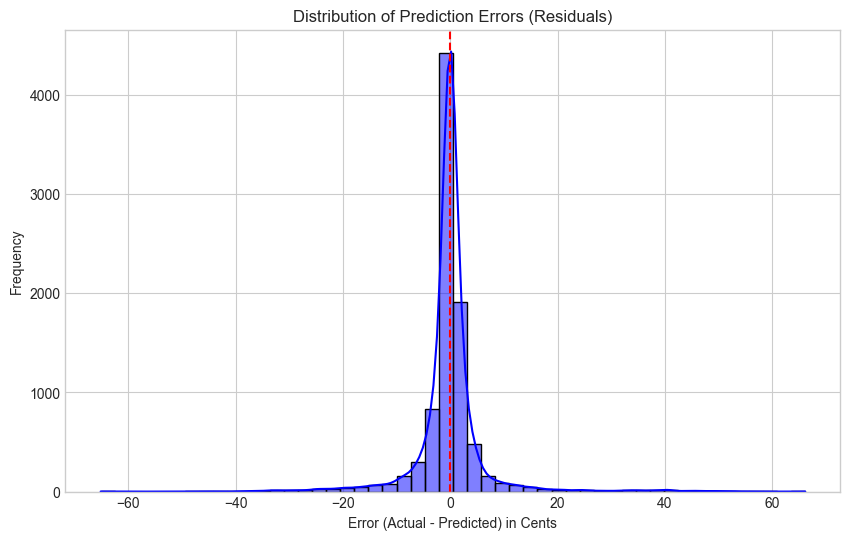

In [12]:
residuals = y_test - predictions
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50, color='blue')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted) in Cents')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')
plt.show()

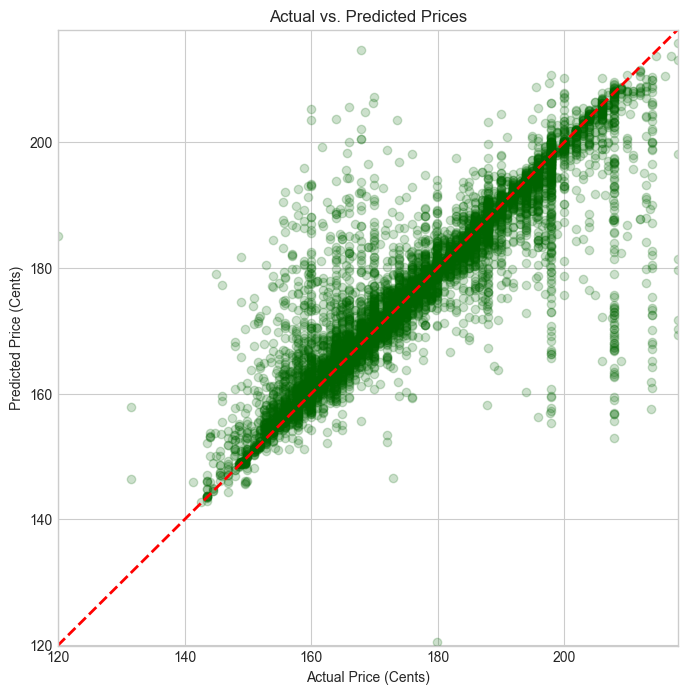

In [13]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, alpha=0.2, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Prices')
# Tighten the limits to see the "core" of the data
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.xlabel('Actual Price (Cents)')
plt.ylabel('Predicted Price (Cents)')
plt.show()

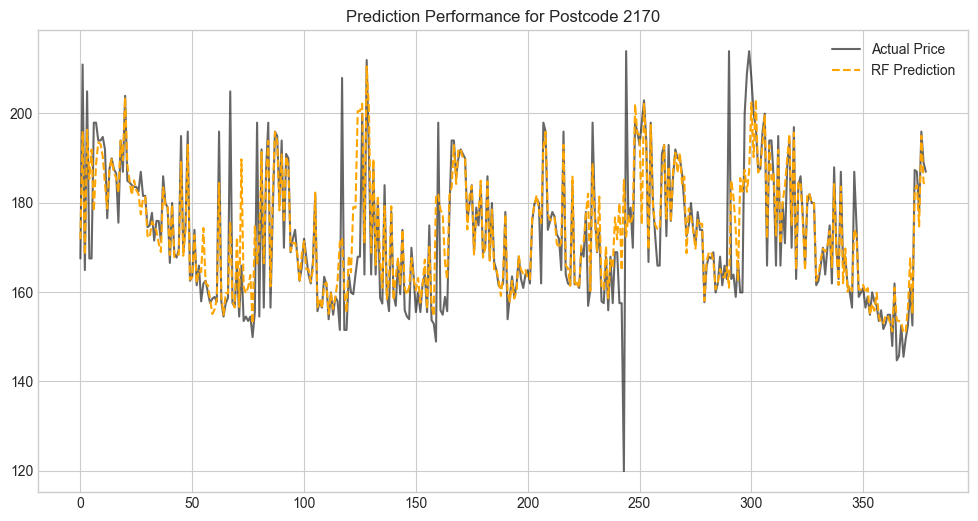

In [14]:
# Create a small dataframe for the test results
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = predictions

# Pick one postcode to visualize (e.g., the most common one)
sample_postcode = test_results['postcode'].mode()[0]
sample_data = test_results[test_results['postcode'] == sample_postcode].sort_index()

plt.figure(figsize=(12, 6))
plt.plot(sample_data['actual'].values, label='Actual Price', color='black', alpha=0.6)
plt.plot(sample_data['predicted'].values, label='RF Prediction', color='orange', linestyle='--')
plt.title(f'Prediction Performance for Postcode {sample_postcode}')
plt.legend()
plt.show()

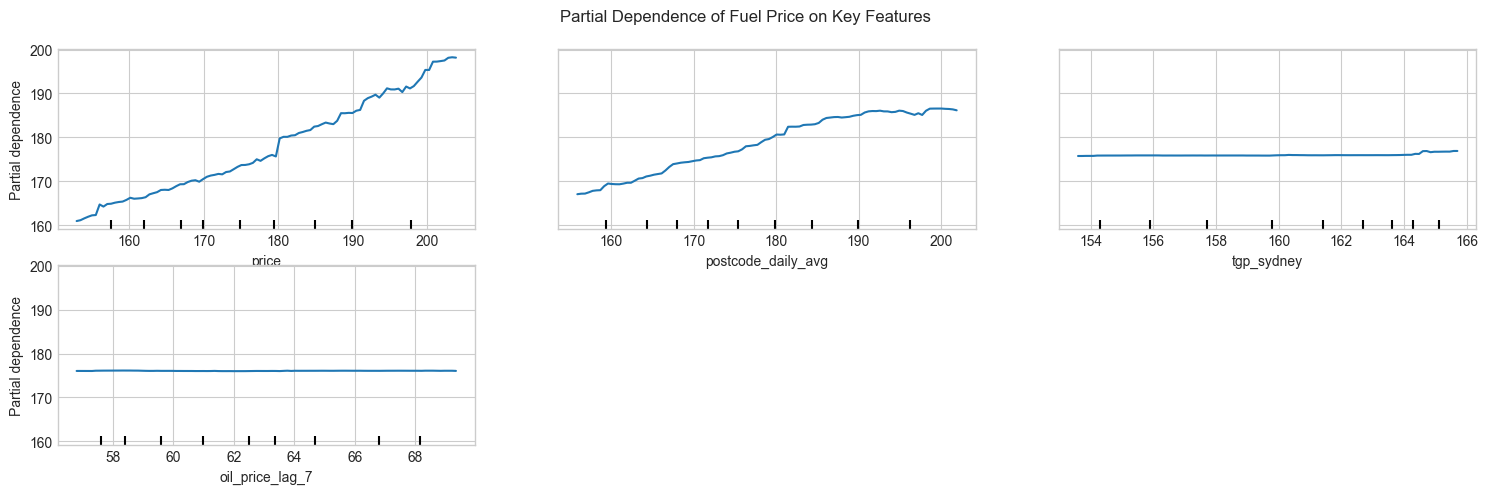

In [15]:
from sklearn.inspection import PartialDependenceDisplay

# Choose the top 3-4 features from your importance list
features_to_plot = ['price', 'postcode_daily_avg', 'tgp_sydney', 'oil_price_lag_7']

fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(model, X_train, features_to_plot, ax=ax)
plt.suptitle('Partial Dependence of Fuel Price on Key Features')
plt.tight_layout()
plt.show()

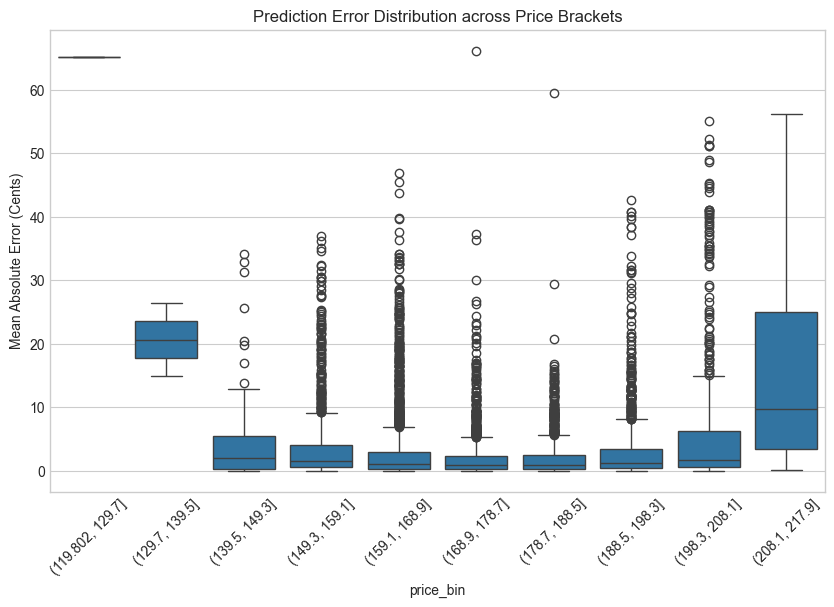

In [16]:
test_results = pd.DataFrame({'actual': y_test, 'predicted': predictions})
test_results['error'] = (test_results['actual'] - test_results['predicted']).abs()

# Bin the prices into $0.10 increments
test_results['price_bin'] = pd.cut(test_results['actual'], bins=10)

plt.figure(figsize=(10, 6))
sns.boxplot(x='price_bin', y='error', data=test_results)
plt.xticks(rotation=45)
plt.title('Prediction Error Distribution across Price Brackets')
plt.ylabel('Mean Absolute Error (Cents)')
plt.show()

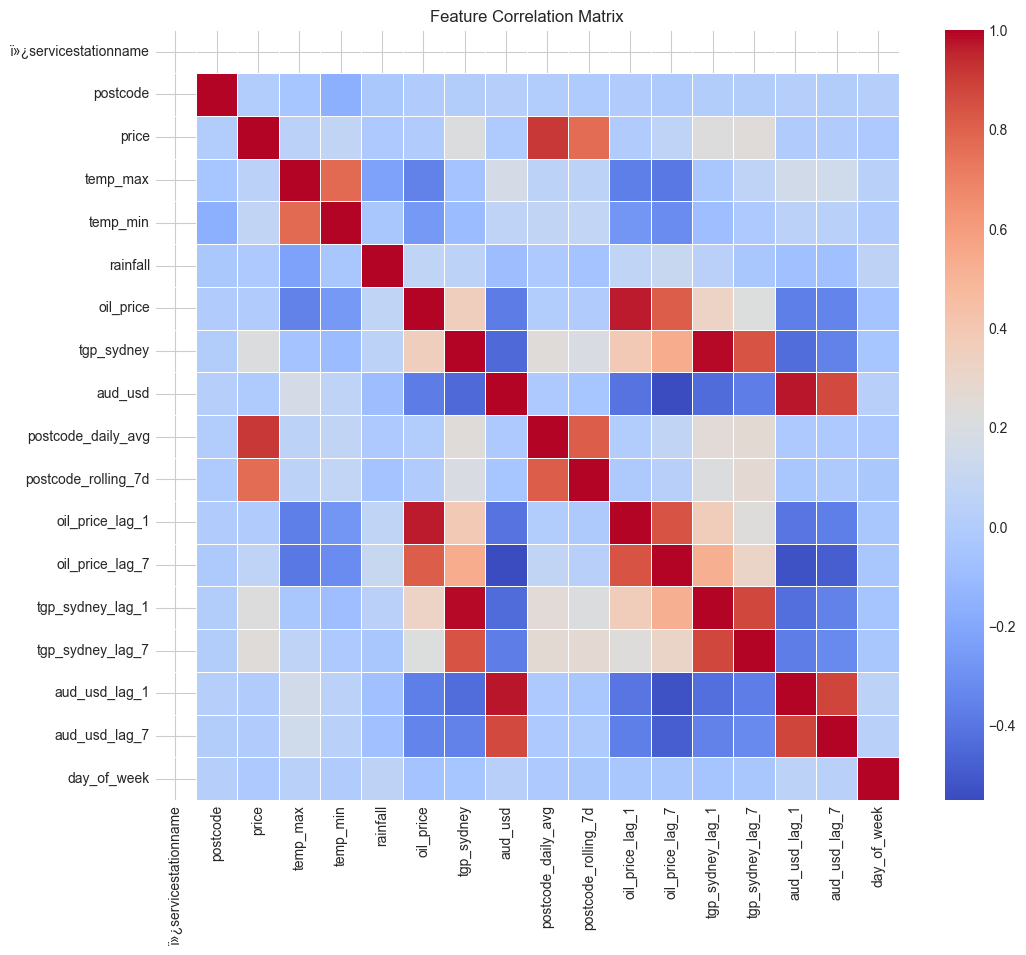

In [17]:
plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

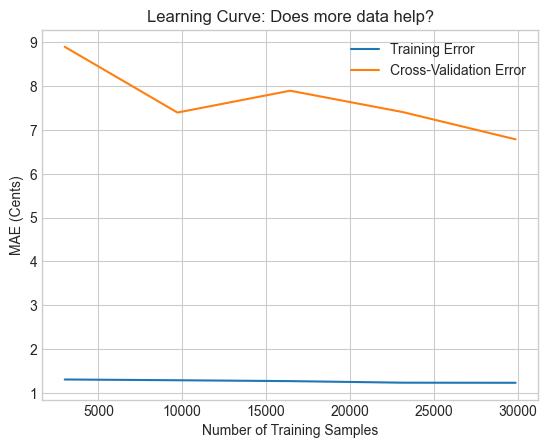

In [18]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(n_estimators=20, n_jobs=-1), X, y, cv=3, 
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_mean_absolute_error'
)

plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Error')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Cross-Validation Error')
plt.title('Learning Curve: Does more data help?')
plt.xlabel('Number of Training Samples')
plt.ylabel('MAE (Cents)')
plt.legend()
plt.show()